In [2]:
import matplotlib.pyplot as plt
import numpy as np
import csv
import math

In [4]:
def prev_csv(data):
    list_data = []
    flag = 0
    for row in data:
        if flag == 0:
            flag += 1
        else:
            l = list(row)
            t = [float(i) for i in l]
            list_data.append(t)
    return list_data

Функция для "преврашения" файла с расширением csv в список

In [5]:
def data_normalized(list_dt, mean=None, std=None):
    if mean is None or std is None:
        mean = [0 for i in range(len(list_dt[0]) - 1)]
        for i in range(len(list_dt)):
            for j in range(len(list_dt[i]) - 1):
                mean[j] += list_dt[i][j]
        for i in range(len(mean)):
            mean[i] /= len(list_dt)
        std = [0 for i in range(len(mean))]
        for i in range(len(list_dt)):
            for j in range(len(list_dt[i]) - 1):
                std[j] += (list_dt[i][j] - mean[j]) ** 2
        for i in range(len(std)):
            std[i] /= len(list_dt)
            std[i] = std[i] ** 0.5
    else:
        mean = mean
        std = std
    new_list_dt = []
    for i in range(len(list_dt)):
        row_i = []
        for j in range(len(list_dt[i]) - 1):
            x_i_j = (list_dt[i][j] - mean[j]) / std[j]
            row_i.append(x_i_j)
        row_i.append(list_dt[i][-1])
        new_list_dt.append(row_i)
    return new_list_dt, mean, std

Функция, которая нормализует данные и любой диапазон меняет на диапазон от -1 до 1

In [6]:
def errors(data, v, b):
    mse = 0
    mn = 0
    for i in range(len(data)):
        pred = b
        for j in range(len(v)):
            pred += v[j] * data[i][j]
        err = data[i][-1] - pred
        mse += err * err
        mn += data[i][-1]
    mse /= len(data)
    rmse = mse ** 0.5

    mn /= len(data)
    ss_total = 0
    ss_res = 0
    for i in range(len(data)):
        pred = b
        for j in range(len(v)):
            pred += v[j] * data[i][j]
        ss_total += (mn - data[i][-1]) ** 2
        ss_res += (data[i][-1] - pred) ** 2

    r = 1 - ss_res / ss_total

    return mse, rmse, r

Функция возващающая три вида метрик: $MSE, RMSE, R^{2}$

In [7]:
def gradient(w, b, data, number_of_sings=20):
    grad = [0 for i in range(number_of_sings)]
    gradb = 0
    for i in range(len(data)):
        pred = b
        for j in range(number_of_sings):
            pred += w[j] * data[i][j]
        err = pred - data[i][-1]
        for j in range(number_of_sings):
            grad[j] += err * data[i][j] * 2
        gradb += err * 2
    for i in range(number_of_sings):
        grad[i] /= len(data)
    gradb /= len(data)
    return grad, gradb

Функция gradient считает градит от функции ошибки:
$$MSE=\frac{1}{n}\sum(y_i-y_{real})^2$$
Где $y_i$ это предсказанная цена, полученная перемножением текущих весов на параметры i-ой квартиры.

$y_{real}$ - реальная цена i-ой квартиры

$n$ - количество квартир

Стоит также отметить, что возвращается градиент от параметров и градиент от свободного члена отдельно

In [8]:
file = open("dataset_sample_3000.csv", 'r')
train_data = csv.reader(file)
train_list_data = prev_csv(train_data)
file.close()
train_list_data, mean, std = data_normalized(train_list_data)

file = open('dataset_sample_all.csv','r')
test_data = csv.reader(file)
test_list_data = prev_csv(test_data)
file.close()
test_list_data, mean, std = data_normalized(test_list_data, mean, std)

In [12]:
def find_weight_momentum(data, tst_data, number_of_epochs = 140, rate_learning = 0.05, rate_inertion = 0.03):
    x = [0.0 for i in range(20)]
    v = [0.0 for i in range(20)]
    v_b = 0
    b = 0
    history = []
    for i in range(number_of_epochs):
        g, gradb = gradient(x, b, data)
        for j in range(len(x)):
            v[j] = v[j]*rate_inertion- (rate_learning*g[j])
            x[j]+=v[j]
        v_b = v_b*rate_inertion- (rate_learning*gradb)
        b+=v_b
        if i > 60:
            ms, _, r = errors(tst_data, x, b)
            history.append(r)
    return x, b, history

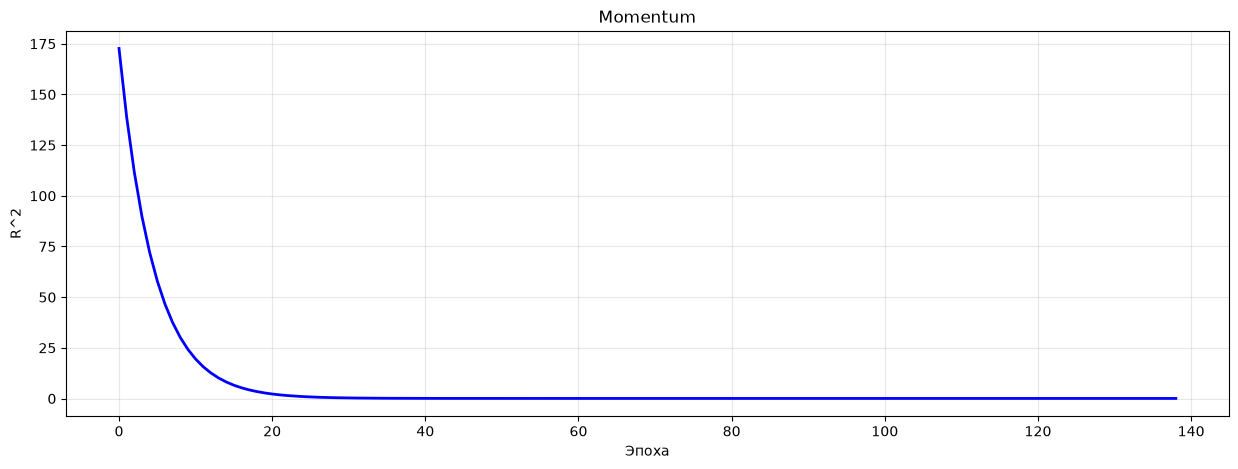

MSE: 0.042546889251231026
RMSE: 0.20626897306970582
R^2: 0.8372859307004898


In [13]:
x, b, history = find_weight_momentum(train_list_data, test_list_data)

mse_test, rmse_test, r_test = errors(test_list_data, x, b)
plt.figure(figsize=(15, 5))
plt.plot(history, color='blue', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('R^2')
plt.title('Momentum')
plt.grid(True, alpha=0.3)
plt.show()
print("MSE:", mse_test)
print("RMSE:", rmse_test)
print("R^2:", r_test)

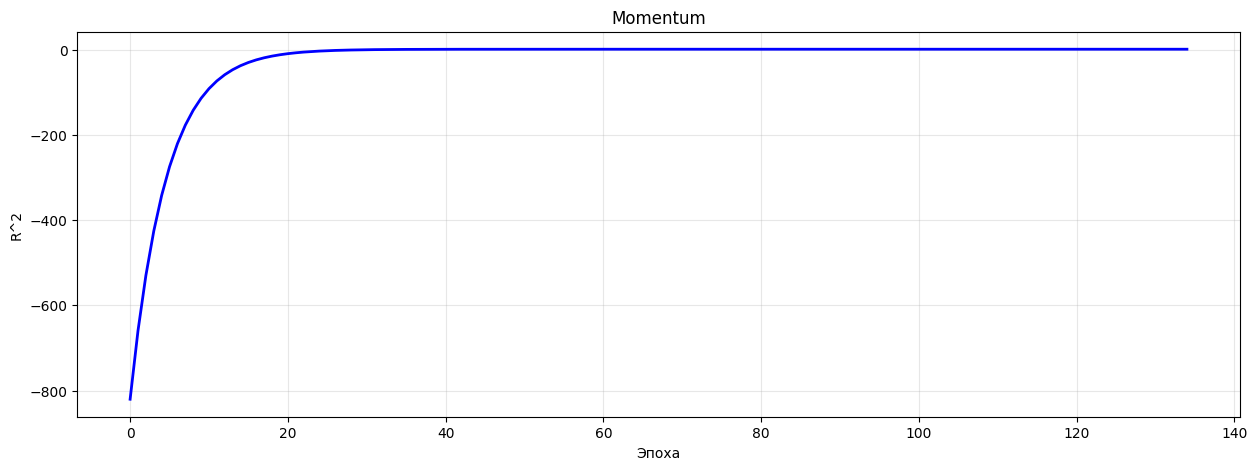Этот график- график ошибки $R^2$ и очевидно что как-то проанализировать его работу просто так не получится. поэтому я добавил некоторое ограничение с какой итерации будет строится график.

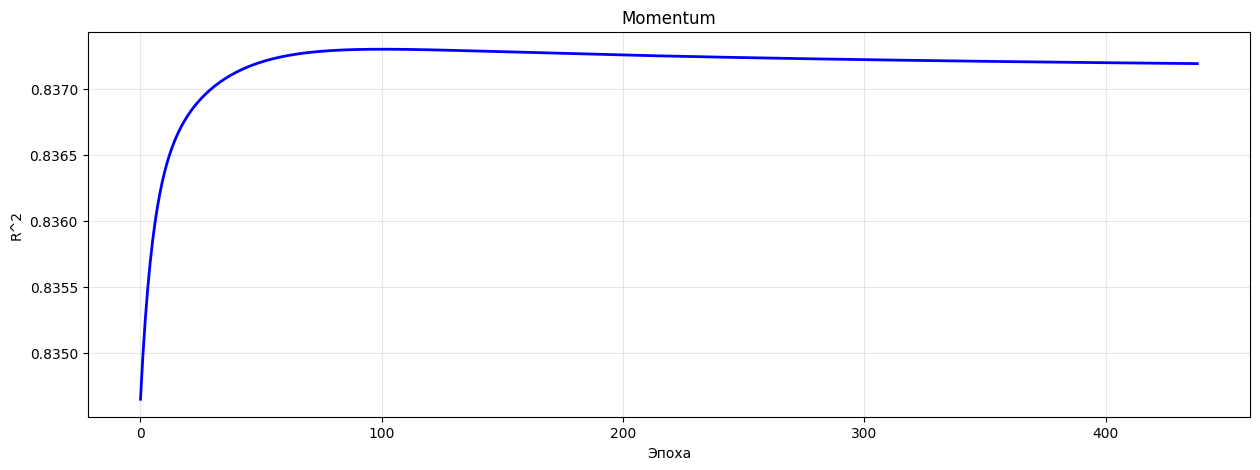
Данный график имеет следующие параметры:
- итерации после 60
- rate_learning = 0.05
- rate_inertion=0.03


Можно заметить, что после 130~140 итерации ошибка идет на спад, то есть показан эффект переобучения

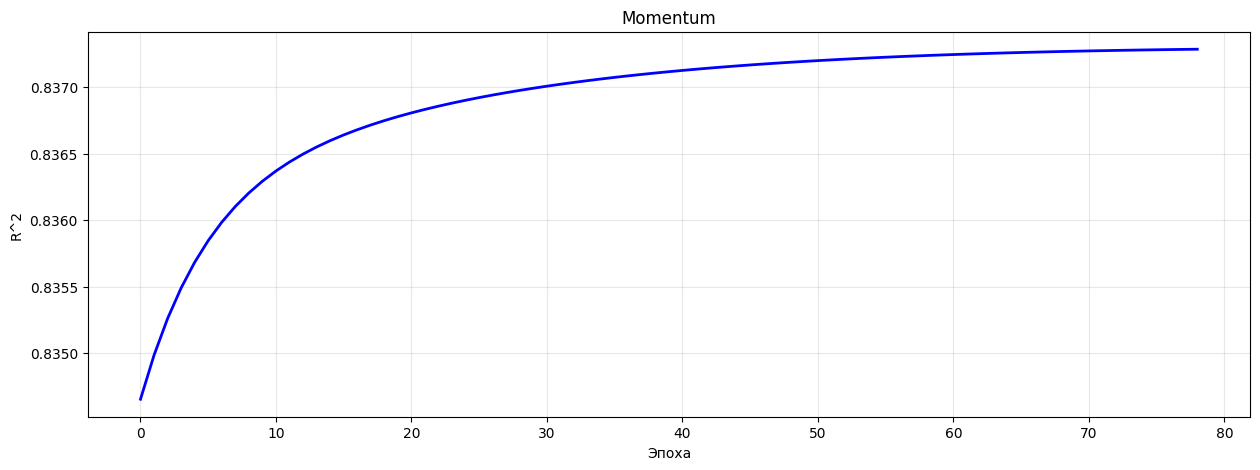
Этот график иллюстрирует что примерно за 140 итераций модель достигает точности $R^2$=0,837

In [12]:
def find_weight_Nesterov_momentum(data, tst_data, number_of_epochs = 120, rate_learning = 0.05, rate_inertion = 0.3):
    x = [0.0 for i in range(20)]
    v = [0.0 for i in range(20)]
    b = 0
    v_b = 0
    history = []
    for i in range(number_of_epochs):
        new_x = [x[j]+v[j]*rate_inertion for j in range(len(x))]
        g, gradb = gradient(new_x, b, data)
        for j in range(len(x)):
            v[j] = v[j]*rate_inertion- (rate_learning*g[j])
            x[j]+=v[j]
        v_b = v_b*rate_inertion- (rate_learning*gradb)
        b+=v_b
        if i > 45:
            ms, _, r = errors(tst_data, x, b)
            history.append(r)
    return x, b, history

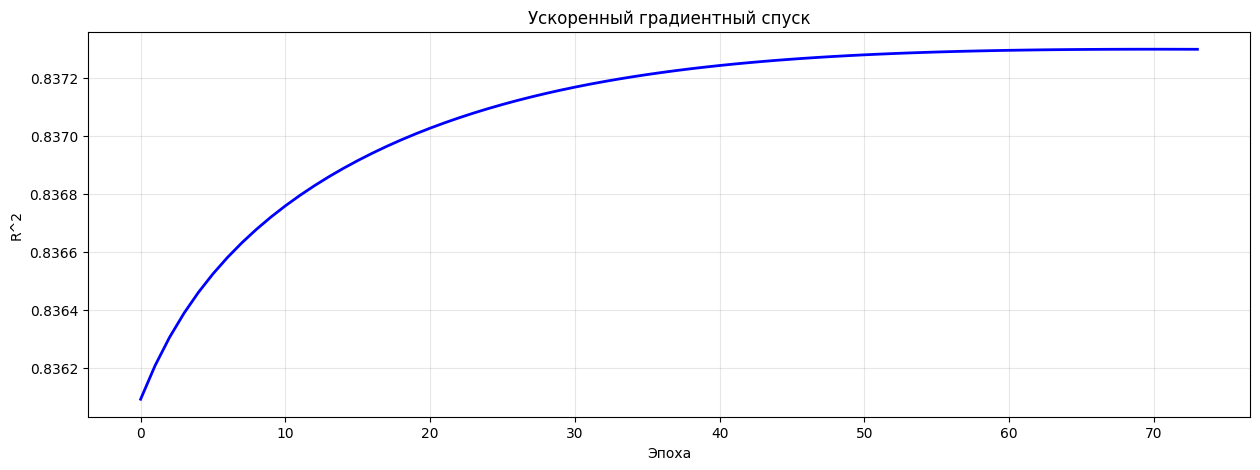

MSE: 0.042543952108621295
RMSE: 0.2062618532560524
R^2: 0.8372971633530892


In [13]:
x, b, history = find_weight_Nesterov_momentum(train_list_data, test_list_data)

mse_test, rmse_test, r_test = errors(test_list_data, x, b)
plt.figure(figsize=(15, 5))
plt.plot(history, color='blue', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('R^2')
plt.title('Ускоренный градиентный спуск')
plt.grid(True, alpha=0.3)
plt.show()
print("MSE:", mse_test)
print("RMSE:", rmse_test)
print("R^2:", r_test)

Аналогично предудщему примеру из-за природы метрики анализировать график мы будет спустя 45 итераций

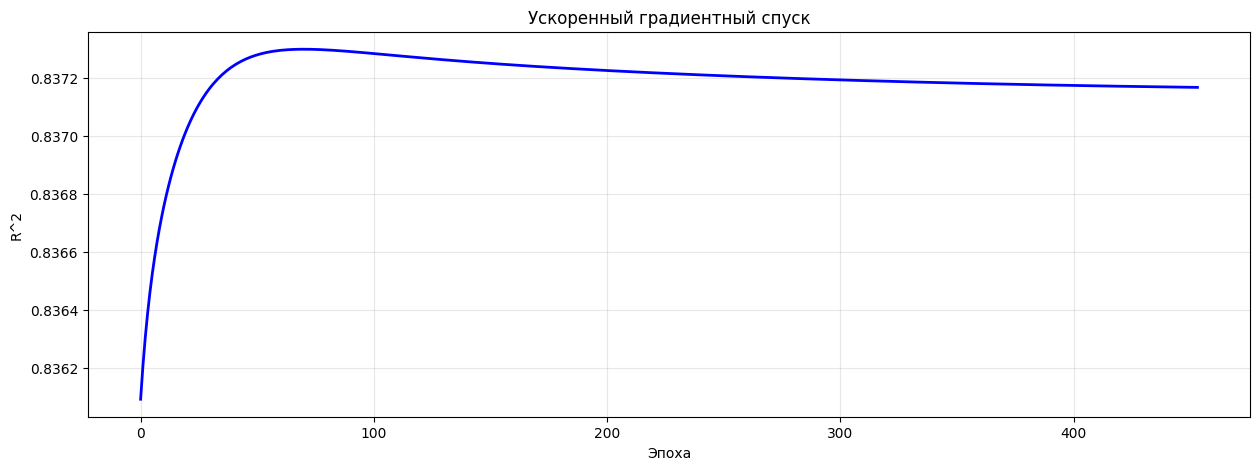
заметно что спустя ~120 итераций также наступает переобучение.

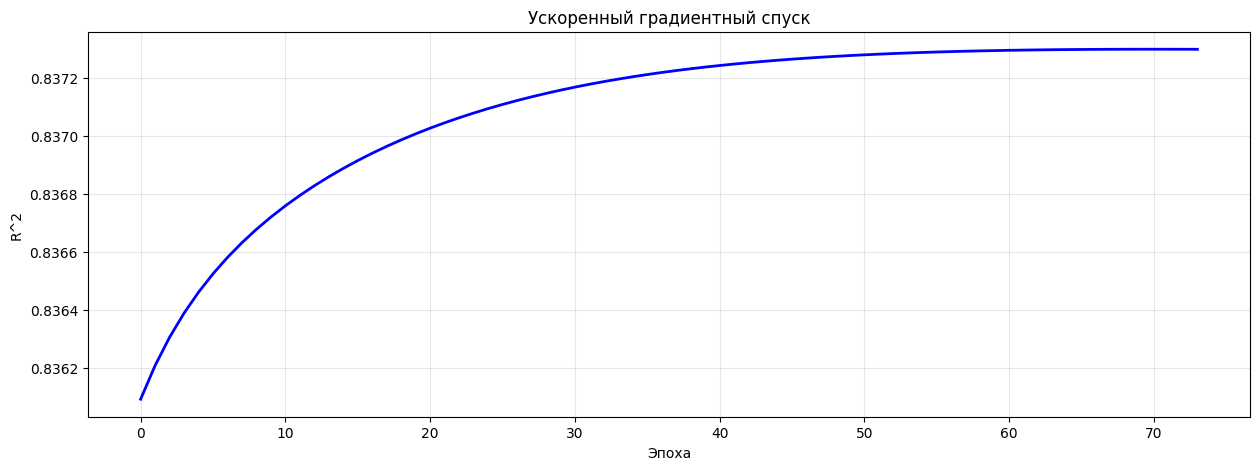
по итогу этот метод сходится примерно к той же точности что и предыдущий за 120 итераций

In [24]:
def elipsoid_method(data, tst_data, number_of_epochs = 1500, radius = 300):
    elipsoid = [[0.0 for i in range(21)] for i in range(21)]
    center = [0 for i in range(21)]
    center[20] = 16
    history = []
    for i in range(21):
        elipsoid[i][i] = radius
    for i in range(number_of_epochs):
        x = center[:20]
        b = center[20]
        g, gradb = gradient(x, b, data)
        g.append(gradb)
        start_h = g
        elipsoid1 = [0 for i in range(21)]
        for k in range(21):
            for j in range(21):
                elipsoid1[k] += elipsoid[k][j] * start_h[j]
        elipsoid2 = 0
        for k in range(21):
            elipsoid2 += elipsoid1[k] * start_h[k]
        h = [0 for i in range(21)]
        for k in range(21):
            h[k] = elipsoid1[k] / (elipsoid2 ** 0.5)

        for k in range(21):
            center[k] -= h[k] / 22

        for k in range(21):
            for j in range(21):
                elipsoid[k][j] -= (2 / 22) * h[k] * h[j]
                elipsoid[k][j] *= (441 / 440)
        if i >1300 :
            ms, _, r = errors(tst_data, x, b)
            history.append(r)
    return center[:20], center[20], history


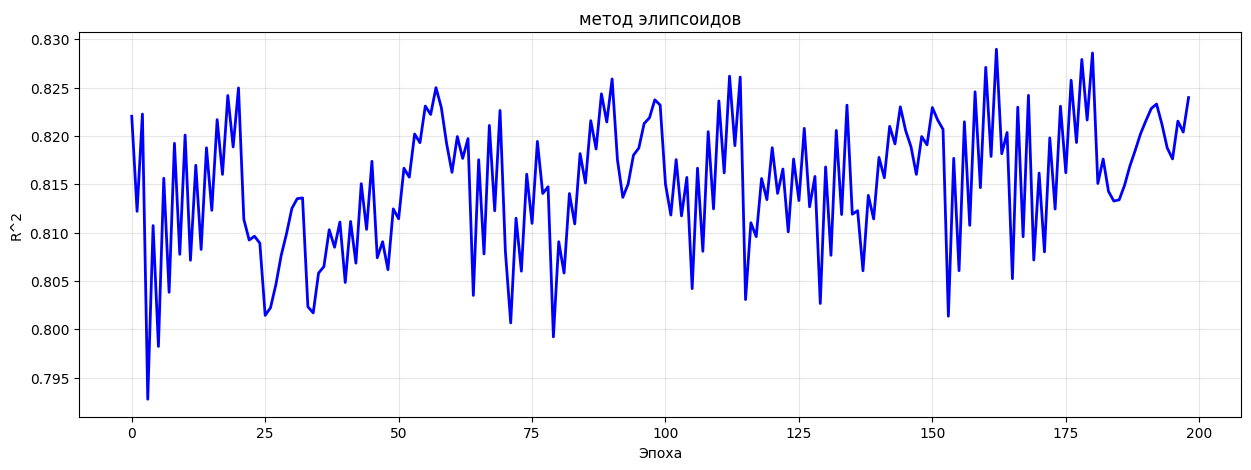

MSE: 0.04630238727583699
RMSE: 0.21517989514784366
R^2: 0.8229236030054697


In [25]:
x, b, history = elipsoid_method(train_list_data, test_list_data)

mse_test, rmse_test, r_test = errors(test_list_data, x, b)
plt.figure(figsize=(15, 5))
plt.plot(history, color='blue', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('R^2')
plt.title('метод элипсоидов')
plt.grid(True, alpha=0.3)
plt.show()
print("MSE:", mse_test)
print("RMSE:", rmse_test)
print("R^2:", r_test)

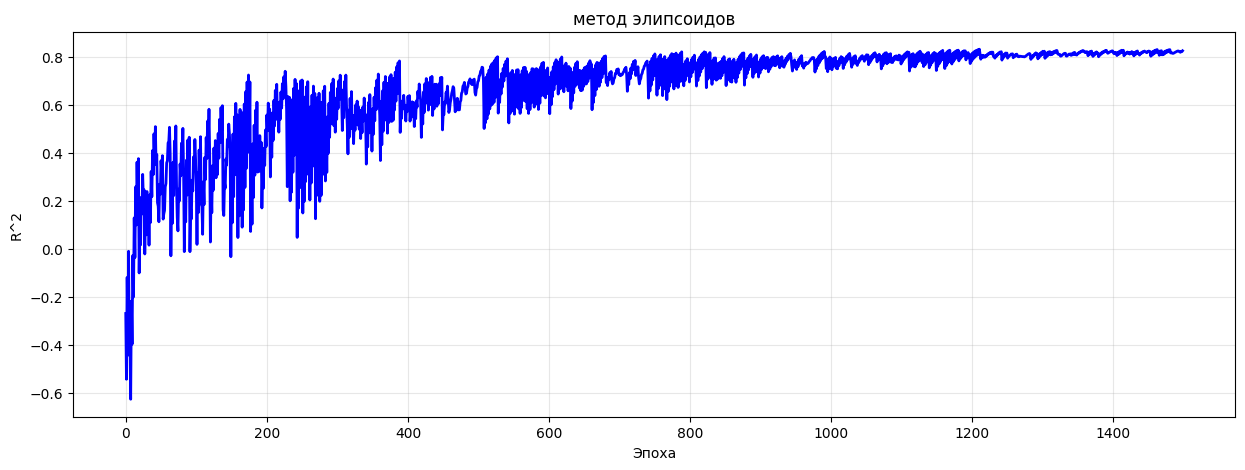
можно заметить что сходится ошибка не плавно, но это в сиу природы метода.

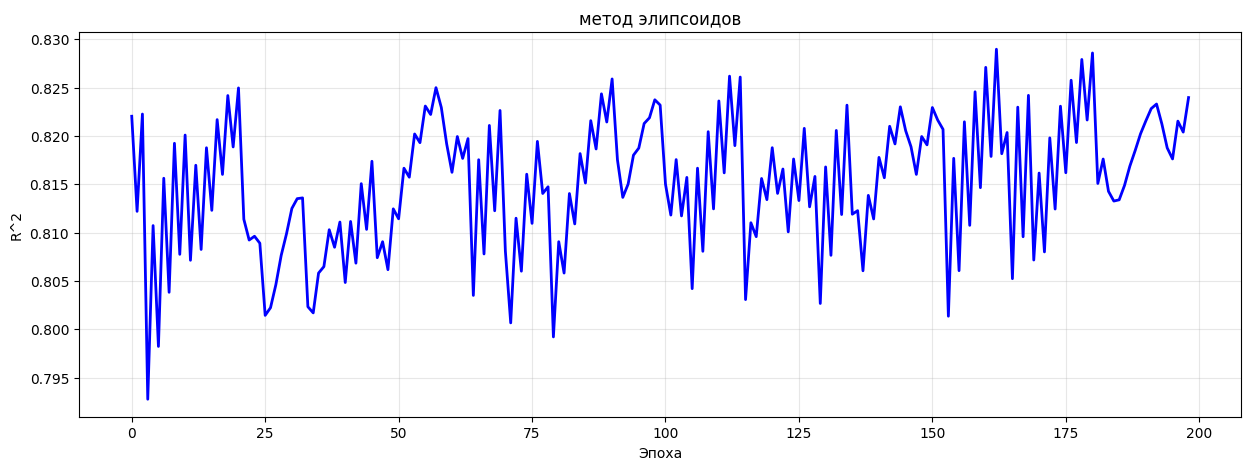
это итерации с 1300-1500. Даже если значения очень "скачущие" метод постепенно сходится, правда делает это очень медленно.

| Метод | сходимость(кол-во итераций)
|-------|-----|
| Momentum | 140 |  
| Nesterov |  120|  
| Эллипсоиды | 1500 |

Вывод: Лучше всех из реализованных методов показал себя ускоренный градиентный спуск. Скорее всего его и надо было использовать для данной задачи. В свою очередь метод эллипсоидов показал бы себя лучше на более сложных задачах.